# Lab Assignment 9: Resampling Techniques

# Virat Shrimali - 202303061

## Objective

This lab studies two fundamentally different stochastic sampling systems:

1. **Barnsley Fern (Markov Chain Simulation)**
2. **Rejection Sampling (Monte Carlo Sampling)**

---

## Problem Structure

### Problem 16
Simulate a stochastic dynamical system using affine transformations and interpret it as a Markov chain.

### Problem 17
Use rejection sampling to generate samples from a Laplace distribution using a Gaussian proposal.

---

## Key Concepts

- Markov chains
- Stationary behavior
- Random transformations
- Monte Carlo sampling
- Envelope methods

---

## Core Goal

Understand how randomness + structure can generate:
- Complex geometric patterns (Fern)
- Samples from difficult distributions (Laplace)

# Problem 16: Barnsley Fern and Markov Chains

## Objective

The goal is to simulate a stochastic dynamical system defined by affine transformations and interpret it as a Markov chain.

---

## Mathematical Model

We define a sequence of states:
$$
x_0, x_1, x_2, \dots \in \mathbb{R}^2
$$

Initial state:
$$
x_0 = \begin{bmatrix}0 \\ 0\end{bmatrix}
$$

Update rule:
$$
x_{n+1} = A_i x_n + b_i
$$

where index $i \in \{1,2,3,4\}$ is chosen randomly with fixed probabilities.

---

## Interpretation

- Each step applies a random affine transformation
- The system evolves stochastically
- Over time, the points converge to a structured geometric pattern (fractal)

---

## Key Insight

The system is not deterministic, but governed by:
- transition rules
- probabilistic selection

This makes it a **stochastic iterative system**

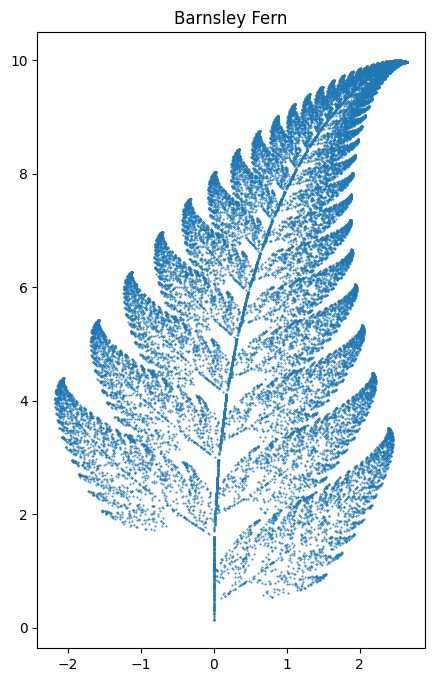

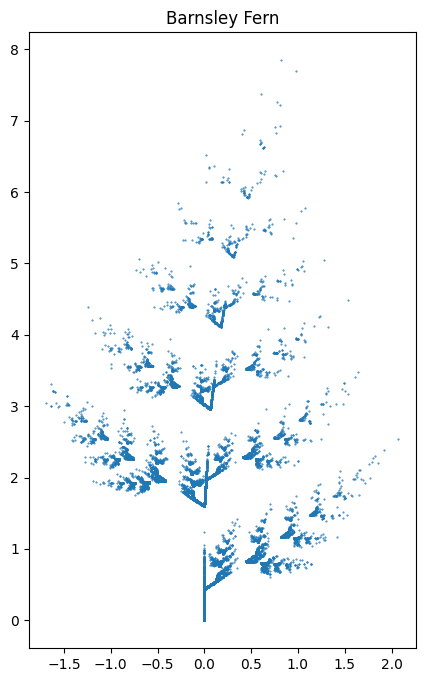

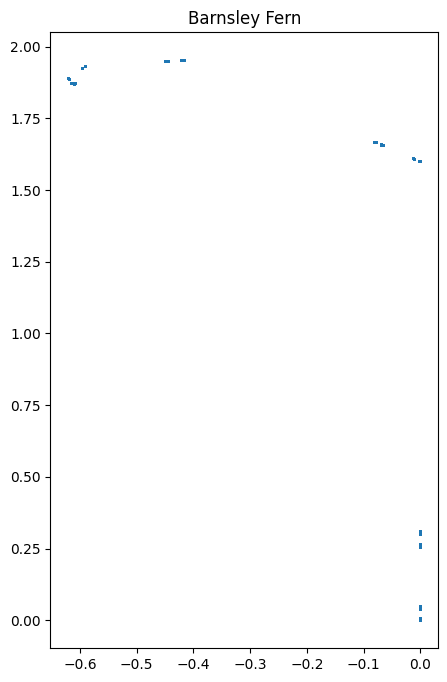

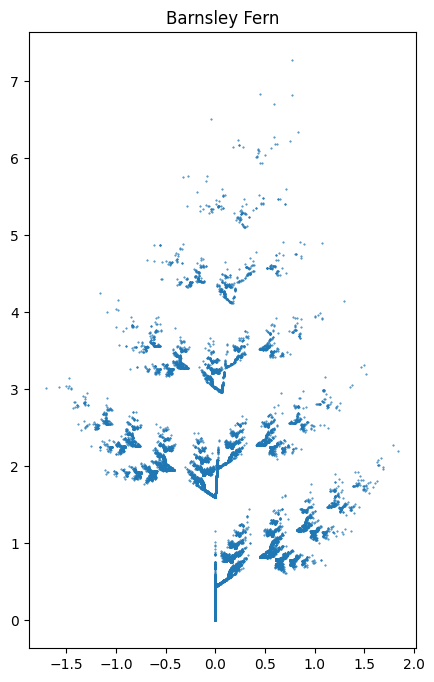

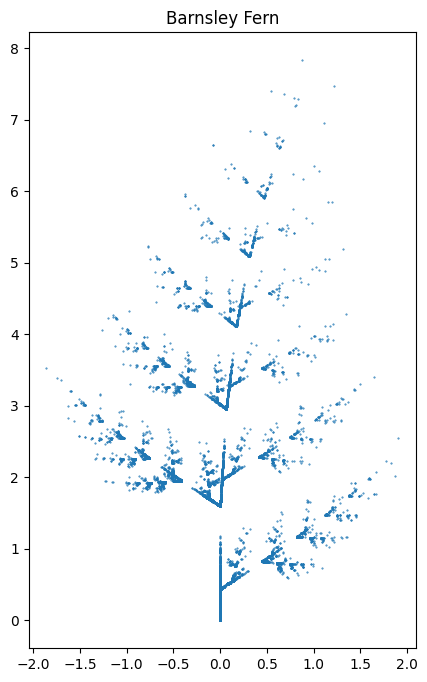

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define transformations
A = [
    np.array([[0, 0], [0, 0.16]]),
    np.array([[0.85, 0.04], [-0.04, 0.85]]),
    np.array([[0.20, -0.26], [0.23, 0.22]]),
    np.array([[-0.15, 0.28], [0.26, 0.24]])
]

b = [
    np.array([0, 0]),
    np.array([0, 1.6]),
    np.array([0, 1.6]),
    np.array([0, 0.44])
]

p = [0.01, 0.85, 0.07, 0.07]
p1 = [0.25, 0.25, 0.25, 0.25]
p2 = [0.5, 0, 0.5, 0]
p3 = [0.1, 0.2, 0.3, 0.4]
p4 = [0.4, 0.3, 0.2, 0.1]

def barnsley_fern(p, n_points=30000):
    x = np.array([0.0, 0.0])
    points = []

    for _ in range(n_points):
        i = np.random.choice(4, p=p)
        x = A[i] @ x + b[i]
        points.append(x.copy())

    return np.array(points)

points = barnsley_fern(p)

plt.figure(figsize=(5,8))
plt.scatter(points[:,0], points[:,1], s=0.2)
plt.title("Barnsley Fern")
plt.show()

points = barnsley_fern(p1)

plt.figure(figsize=(5,8))
plt.scatter(points[:,0], points[:,1], s=0.2)
plt.title("Barnsley Fern")
plt.show()

points = barnsley_fern(p2)

plt.figure(figsize=(5,8))
plt.scatter(points[:,0], points[:,1], s=0.2)
plt.title("Barnsley Fern")
plt.show()

points = barnsley_fern(p3)

plt.figure(figsize=(5,8))
plt.scatter(points[:,0], points[:,1], s=0.2)
plt.title("Barnsley Fern")
plt.show()

points = barnsley_fern(p4)

plt.figure(figsize=(5,8))
plt.scatter(points[:,0], points[:,1], s=0.2)
plt.title("Barnsley Fern")
plt.show()

## Markov Chain Interpretation

### State Definition

The state of the system at time $n$ is:
$$
x_n \in \mathbb{R}^2
$$

---

### Markov Property

A process is a Markov chain if:
$$
P(x_{n+1} \mid x_n, x_{n-1}, \dots) = P(x_{n+1} \mid x_n)
$$

---

### Verification

The update rule is:
$$
x_{n+1} = A_i x_n + b_i
$$

where $i$ is sampled independently at each step.

Thus:
- $x_{n+1}$ depends only on $x_n$
- no dependence on past states

---

### Conclusion

The system satisfies the Markov property, hence it is a **Markov chain**.

### Experiment: Effect of $(A_i, b_i, p_i)$ on Barnsley Fern (IFS)

The Barnsley fern is generated using an **Iterated Function System (IFS)**:
$$
x_{k+1} = A_i x_k + b_i \quad \text{with probability } p_i
$$

Each transformation $(A_i, b_i)$ is an **affine map**:
- $A_i$ controls **linear transformation** (scaling, rotation, shear)
- $b_i$ controls **translation (position shift)**
- $p_i$ controls **how frequently** each transformation is applied

---

### 🔹 Role of $A_i$ (Geometry Control)

Matrix $A_i$ determines:
- **Scaling** → controls size of substructures
- **Rotation** → changes orientation of leaves
- **Shear** → distorts symmetry

👉 Small changes in $A_i$ can:
- bend the fern
- widen/narrow leaves
- distort symmetry

---

### 🔹 Role of $b_i$ (Spatial Placement)

Vector $b_i$ shifts transformed points:
- Moves components vertically/horizontally
- Controls where sub-leaves appear

👉 Changing $b_i$:
- shifts leaf clusters
- affects overlap structure
- can break alignment of the fern stem

---

### 🔹 Role of $p_i$ (Density Control)

Probabilities determine **how often** each transformation is used.

Important:
- The **shape (support)** of the fractal depends only on $(A_i, b_i)$
- The **visual density** depends on $p_i$

👉 Increasing $p_i$:
- makes that transformation's region **denser**
- highlights certain parts (e.g., stem vs leaves)

---

### 🔹 Key Insight

- $(A_i, b_i)$ → defines the **geometry (structure)**
- $p_i$ → defines the **measure (density distribution)**

Thus:
- Changing $A_i, b_i$ → changes the *shape*
- Changing $p_i$ → changes the *appearance/intensity*

---

### 🔹 Goal of Experiment

We vary:
- probabilities $p_i$
- slight perturbations in $A_i$
- small shifts in $b_i$

and observe:
- structural deformation vs density redistribution

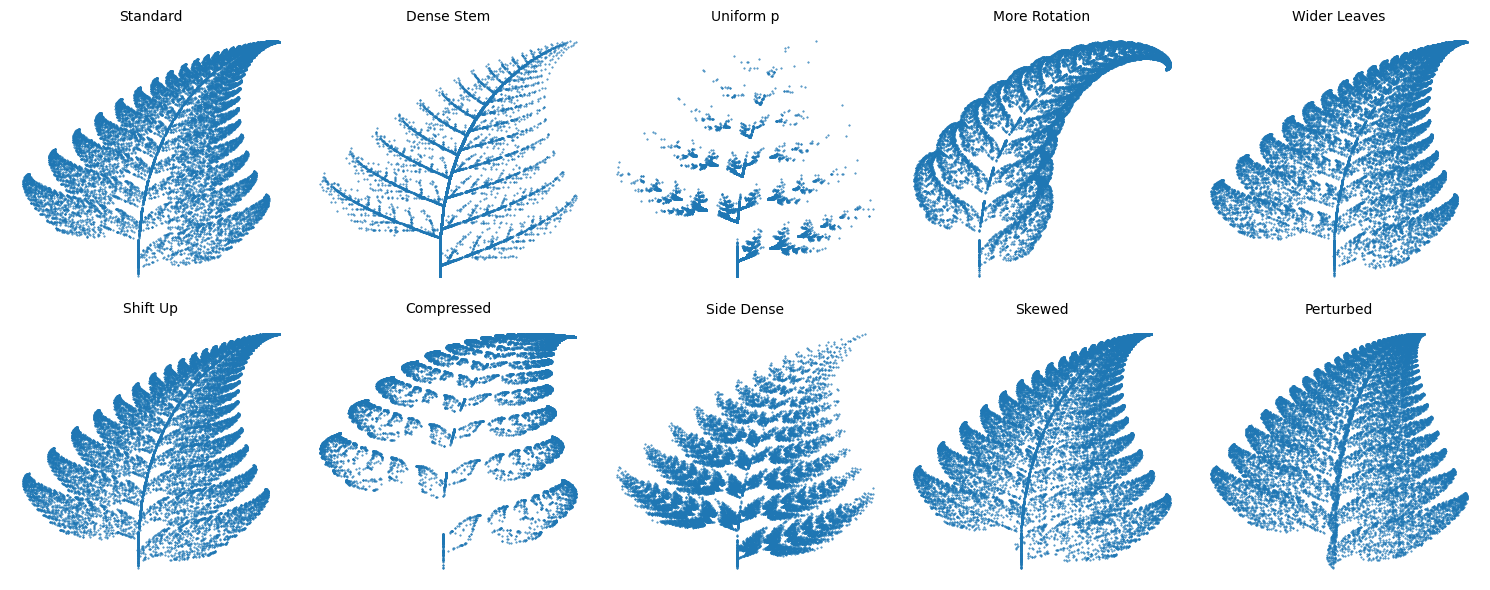

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Base transformations
A_base = [
    np.array([[0, 0], [0, 0.16]]),
    np.array([[0.85, 0.04], [-0.04, 0.85]]),
    np.array([[0.20, -0.26], [0.23, 0.22]]),
    np.array([[-0.15, 0.28], [0.26, 0.24]])
]

b_base = [
    np.array([0, 0]),
    np.array([0, 1.6]),
    np.array([0, 1.6]),
    np.array([0, 0.44])
]

def barnsley_fern(A, b, probs, n_points=20000, burn_in=100):
    x = np.array([0.0, 0.0])
    points = np.zeros((n_points, 2))

    for i in range(n_points + burn_in):
        idx = np.random.choice(4, p=probs)
        x = A[idx] @ x + b[idx]
        if i >= burn_in:
            points[i - burn_in] = x

    return points

# 10 different experiments
experiments = []

# 1. Standard
experiments.append((A_base, b_base, [0.01, 0.85, 0.07, 0.07], "Standard"))

# 2. More stem density
experiments.append((A_base, b_base, [0.2, 0.7, 0.05, 0.05], "Dense Stem"))

# 3. Uniform probabilities
experiments.append((A_base, b_base, [0.25, 0.25, 0.25, 0.25], "Uniform p"))

# 4. Slight rotation tweak
A_mod = A_base.copy()
A_mod[1] = np.array([[0.85, 0.1], [-0.1, 0.85]])
experiments.append((A_mod, b_base, [0.01, 0.85, 0.07, 0.07], "More Rotation"))

# 5. Wider leaves
A_mod = A_base.copy()
A_mod[2] = np.array([[0.3, -0.3], [0.2, 0.2]])
experiments.append((A_mod, b_base, [0.01, 0.85, 0.07, 0.07], "Wider Leaves"))

# 6. Shifted upward
b_mod = b_base.copy()
b_mod[1] = np.array([0, 2.0])
experiments.append((A_base, b_mod, [0.01, 0.85, 0.07, 0.07], "Shift Up"))

# 7. Compressed vertically
A_mod = A_base.copy()
A_mod[1] = np.array([[0.85, 0.04], [-0.04, 0.7]])
experiments.append((A_mod, b_base, [0.01, 0.85, 0.07, 0.07], "Compressed"))

# 8. Emphasize side leaves
experiments.append((A_base, b_base, [0.01, 0.6, 0.2, 0.19], "Side Dense"))

# 9. Skewed structure
A_mod = A_base.copy()
A_mod[3] = np.array([[-0.2, 0.35], [0.3, 0.2]])
experiments.append((A_mod, b_base, [0.01, 0.85, 0.07, 0.07], "Skewed"))

# 10. Random slight perturbation
np.random.seed(0)
A_mod = [a + 0.02*np.random.randn(2,2) for a in A_base]
experiments.append((A_mod, b_base, [0.01, 0.85, 0.07, 0.07], "Perturbed"))

# Plot grid
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, (A, b, p, title) in zip(axes.flatten(), experiments):
    pts = barnsley_fern(A, b, p)
    ax.scatter(pts[:,0], pts[:,1], s=0.2)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

# # Define transformations
# A = [
#     np.array([[0, 0], [0, 0.16]]),
#     np.array([[0.85, 0.04], [-0.04, 0.85]]),
#     np.array([[0.0, -0.26], [0.23, 0.22]]),
#     np.array([[-0.15, 0.28], [0.26, 0.24]])
# ]

# b = [
#     np.array([0, 0]),
#     np.array([0, 0.6]),
#     np.array([0, 2.6]),
#     np.array([0, 0.44])
# ]

# p1 = [0.2, 0.65, 0.07, 0.08] ## changed
# p2 = [0.25, 0.25, 0.25, 0.25] ## changed
# p3 = [0.10, 0, 0, 0.90] ## changed
# p = [p1,p2,p3]
# def barnsley_fern(probs, n_points=30000):
#     x = np.array([0.0, 0.0])
#     points = []

#     for _ in range(n_points):
#         i = np.random.choice(4, p=probs)
#         x = A[i] @ x + b[i]
#         points.append(x.copy())

#     return np.array(points)

# points = barnsley_fern(p[0])

# plt.figure(figsize=(5,8))
# plt.scatter(points[:,0], points[:,1], s=0.2)
# plt.title("Barnsley Fern")
# plt.show()

# points = barnsley_fern(p[1])

# plt.figure(figsize=(5,8))
# plt.scatter(points[:,0], points[:,1], s=0.2)
# plt.title("Barnsley Fern")
# plt.show()

# oints = barnsley_fern(p[2])

# plt.figure(figsize=(5,8))
# plt.scatter(points[:,0], points[:,1], s=0.2)
# plt.title("Barnsley Fern")
# plt.show()

# Problem 17: Rejection Sampling

## Objective

Sample from a Laplace distribution using rejection sampling with a Gaussian proposal.

---

## Target Distribution

We want to sample from:
$$
\pi(x) \propto f(x) = e^{-|x|}
$$

This is the Laplace distribution (unnormalized).

---

## Proposal Distribution

We choose:
$$
g(x) = \mathcal{N}(0, \sigma^2)
$$

Properties:
- Easy to sample
- Defined over $\mathbb{R}$
- Matches support of target

---

## Key Requirement

We need a constant $M$ such that:
$$
f(x) \le M g(x), \quad \forall x
$$

---

## Goal

Use $g(x)$ to generate candidate samples and accept/reject to obtain samples from $f(x)$.

---

## Finding the Constant $M$ (Corrected)

We compute:
$$
\frac{f(x)}{g(x)} = \sqrt{2\pi\sigma^2} \cdot e^{- |x| + \frac{x^2}{2\sigma^2}}
$$

Let:
$$
\phi(x) = -|x| + \frac{x^2}{2\sigma^2}
$$

---

### Step 1: Symmetry

Since the expression is symmetric, analyze $x \ge 0$:
$$
\phi(x) = -x + \frac{x^2}{2\sigma^2}
$$

---

### Step 2: Critical Point

$$
\frac{d\phi}{dx} = -1 + \frac{x}{\sigma^2} = 0
\Rightarrow x = \sigma^2
$$

Value:
$$
\phi(\sigma^2) = -\frac{\sigma^2}{2}
$$

---

### Step 3: Check $x = 0$

$$
\phi(0) = 0
$$

---

### Step 4: Compare

At $x = 0$:
$$
\frac{f(x)}{g(x)} = \sqrt{2\pi\sigma^2}
$$

At $x = \sigma^2$:
$$
= \sqrt{2\pi\sigma^2} \cdot e^{-\sigma^2/2}
$$

Since:
$$
e^{-\sigma^2/2} < 1
$$

---

### Final Result

$$
M = \sqrt{2\pi\sigma^2}
$$

## Rejection Sampling Implementaion

In [47]:
def laplace_target(x):
    return np.exp(-abs(x))

def normal_proposal_pdf(x, sigma):
    return (1 / np.sqrt(2*np.pi*sigma**2)) * np.exp(-x**2/(2*sigma**2))

def compute_M(sigma):
    return np.sqrt(2 * np.pi * sigma**2)

def rejection_sampling_laplace(n_samples, sigma):
    M = compute_M(sigma)
    samples = []
    trials = 0

    while len(samples) < n_samples:
        x = np.random.normal(0, sigma)
        u = np.random.rand()
        trials += 1

        acceptance_ratio = laplace_target(x) / (M * normal_proposal_pdf(x, sigma))

        if u <= acceptance_ratio:
            samples.append(x)

    return np.array(samples), trials, M
samples, trials, M = rejection_sampling_laplace(10000, sigma=1.0)

print("Acceptance rate:", len(samples)/trials)
print("Theoretical:", 2/M)
print("Trials:", trials)

samples, trials, M = rejection_sampling_laplace(50000, sigma=1.0)

print("Acceptance rate:", len(samples)/trials)
print("Theoretical:", 2/M)
print("Trials:", trials)




Acceptance rate: 0.736105999263894
Theoretical: 0.7978845608028654
Trials: 13585
Acceptance rate: 0.7338480054011213
Theoretical: 0.7978845608028654
Trials: 68134


## Verification of Sampling

As the number of accepted samples increases:
- The empirical histogram converges to the true density
- The approximation improves due to the Law of Large Numbers:
$$
\hat{p}(x) \to p(x)
$$

The overlay confirms that rejection sampling produces samples from the target distribution.

Additionally, the acceptance rate remains consistent across runs:
$$
P(\text{accept}) \approx \frac{2}{M}
$$

which validates the theoretical analysis.

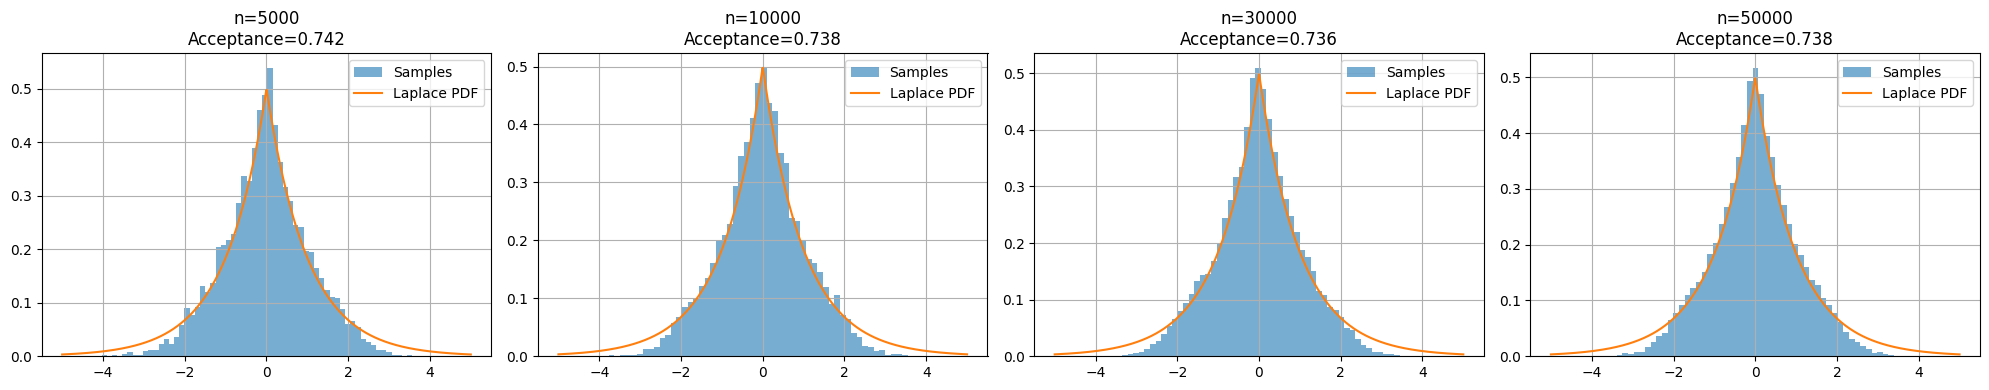

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# True Laplace PDF
x_vals = np.linspace(-5, 5, 1000)
laplace_pdf = 0.5 * np.exp(-np.abs(x_vals))

sizes = [5000, 10000, 30000, 50000]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, n in zip(axes, sizes):
    samples, trials, M = rejection_sampling_laplace(n, sigma=1.0)

    # Restrict samples for fair visualization
    samples_plot = samples[(samples >= -5) & (samples <= 5)]

    ax.hist(samples_plot, bins=60, density=True, alpha=0.6, label="Samples")
    ax.plot(x_vals, laplace_pdf, label="Laplace PDF")

    acceptance_rate = len(samples) / trials

    ax.set_title(f"n={n}\nAcceptance={acceptance_rate:.3f}")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

## Efficiency Analysis

### Problem Setup

We want to sample from a target distribution:
$$
\pi(x) \propto f(x) = e^{-|x|}
$$

using rejection sampling with proposal:
$$
g(x) = \mathcal{N}(0, \sigma^2)
= \frac{1}{\sqrt{2\pi\sigma^2}} e^{-x^2/(2\sigma^2)}
$$

---

### Assumptions

1. **Support condition**:
   $$
   \text{Supp}(f) \subseteq \text{Supp}(g) = \mathbb{R}
   $$

2. **Envelope condition**:
   There exists $M$ such that:
   $$
   f(x) \le M g(x), \quad \forall x
   $$

3. **Definition of $M$**:
   $$
   M = \sup_{x \in \mathbb{R}} \frac{f(x)}{g(x)}
   $$

---

### Acceptance Probability

In rejection sampling:

- Sample $X \sim g(x)$
- Accept with probability:
  $$
  \frac{f(X)}{M g(X)}
  $$

Taking expectation:
$$
P(\text{accept}) = \mathbb{E}_{X \sim g} \left[\frac{f(X)}{M g(X)}\right]
= \frac{1}{M} \int f(x)\,dx
$$

Since:
$$
\int_{-\infty}^{\infty} e^{-|x|} dx = 2
$$

we get:
$$
P(\text{accept}) = \frac{2}{M}
$$

---

### Interpretation

- Acceptance probability is inversely proportional to $M$
- Expected number of trials:
  $$
  \mathbb{E}[\text{trials}] = \frac{M}{2}
  $$

---

## Computing $M$

We compute:
$$
\frac{f(x)}{g(x)}
= \frac{e^{-|x|}}{\frac{1}{\sqrt{2\pi\sigma^2}} e^{-x^2/(2\sigma^2)}}
= \sqrt{2\pi\sigma^2} \cdot e^{- |x| + \frac{x^2}{2\sigma^2}}
$$

Define:
$$
\phi(x) = -|x| + \frac{x^2}{2\sigma^2}
$$

---

### Symmetry Reduction

Since $f(x)$ and $g(x)$ are symmetric:
- analyze $x \ge 0$

Then:
$$
\phi(x) = -x + \frac{x^2}{2\sigma^2}
$$

---

### Maximization

Differentiate:
$$
\frac{d\phi}{dx} = -1 + \frac{x}{\sigma^2}
$$

Set to zero:
$$
x = \sigma^2
$$

---

### Value at Critical Point

$$
\phi(\sigma^2) = -\sigma^2 + \frac{\sigma^4}{2\sigma^2}
= -\sigma^2 + \frac{\sigma^2}{2}
= -\frac{\sigma^2}{2}
$$

Thus:
$$
\left.\frac{f(x)}{g(x)}\right|_{x=\sigma^2}
= \sqrt{2\pi\sigma^2} \cdot e^{-\sigma^2/2}
$$

---

### Boundary Check ($x = 0$)

$$
\left.\frac{f(x)}{g(x)}\right|_{x=0}
= \sqrt{2\pi\sigma^2}
$$

---

### Final Expression for $M$

$$
M = \max \left(
\sqrt{2\pi\sigma^2},\;
\sqrt{2\pi\sigma^2} \cdot e^{-\sigma^2/2}
\right)
$$

Since:
$$
e^{-\sigma^2/2} < 1 \quad \forall \sigma > 0
$$

we conclude:
$$
M = \sqrt{2\pi\sigma^2}
$$

---

## Final Result

### Acceptance Probability

$$
P(\text{accept}) = \frac{2}{\sqrt{2\pi\sigma^2}}
$$

---

### Interpretation of $M(\sigma)$

We define:
$$
M(\sigma)=\sup_x \frac{f(x)}{g(x)}
$$

For the Laplace target and Gaussian proposal:
$$
M(\sigma)=\sqrt{2\pi\sigma^2}
$$

Thus:
- As $\sigma$ increases:
  $$
  g(0) \downarrow \;\Rightarrow\; \frac{f(0)}{g(0)} \uparrow \;\Rightarrow\; M \uparrow
  $$
- As $\sigma$ decreases:
  $$
  g(0) \uparrow \;\Rightarrow\; M \downarrow
  $$

Hence:
$$
P(\text{accept})=\frac{2}{M} \propto \frac{1}{\sigma}
$$

The supremum occurs at $x=0$ for all $\sigma$, so the efficiency is determined by the behavior of the proposal density at the origin.

---

## Conclusion

- Efficiency is controlled by:
  $$
  M = \sup_x \frac{f(x)}{g(x)}
  $$
- Acceptance probability:
  $$
  \propto \frac{1}{M}
  $$
- Optimal $\sigma$ balances:
  - concentration near origin
  - coverage of heavy tails

In [50]:
import numpy as np

# Target (unnormalized Laplace)
def f(x):
    return np.exp(-np.abs(x))

# Proposal: Normal PDF
def g(x, sigma):
    return (1 / np.sqrt(2*np.pi*sigma**2)) * np.exp(-x**2/(2*sigma**2))

# Correct M from derivation
def compute_M(sigma):
    return np.sqrt(2 * np.pi * sigma**2)

# Rejection sampling with tracking
def rejection_sampling_efficiency(n_accept, sigma):
    M = compute_M(sigma)

    accepted = 0
    trials = 0

    while accepted < n_accept:
        x = np.random.normal(0, sigma)
        u = np.random.rand()
        trials += 1

        if u <= f(x) / (M * g(x, sigma)):
            accepted += 1

    empirical_acceptance = accepted / trials
    theoretical_acceptance = 2 / M  # since ∫f(x)dx = 2

    return empirical_acceptance, theoretical_acceptance, M


# Run experiment for different sigma
sigmas = [0.5, 1.0, 2.0, 3.0, 4.0]

for s in sigmas:
    emp, theo, M = rejection_sampling_efficiency(5000, s)
    print(f"σ = {s}")
    print(f"  M = {M:.4f}")
    print(f"  Empirical Acceptance = {emp:.4f}")
    print(f"  Theoretical Acceptance = {theo:.4f}")
    print()

σ = 0.5
  M = 1.2533
  Empirical Acceptance = 0.9464
  Theoretical Acceptance = 1.5958

σ = 1.0
  M = 2.5066
  Empirical Acceptance = 0.7388
  Theoretical Acceptance = 0.7979

σ = 2.0
  M = 5.0133
  Empirical Acceptance = 0.3952
  Theoretical Acceptance = 0.3989

σ = 3.0
  M = 7.5199
  Empirical Acceptance = 0.2670
  Theoretical Acceptance = 0.2660

σ = 4.0
  M = 10.0265
  Empirical Acceptance = 0.1986
  Theoretical Acceptance = 0.1995



## Effect of Proposal Variance $\sigma^2$

### Setup

Target:
$$
f(x) = e^{-|x|}
$$

Proposal:
$$
g(x) = \mathcal{N}(0,\sigma^2)
$$

The efficiency of rejection sampling depends on:
$$
M(\sigma) = \sup_x \frac{f(x)}{g(x)}
$$

From previous derivation:
$$
M(\sigma) = \sqrt{2\pi\sigma^2}
$$

---

## How does $M$ change with $\sigma^2$?

$$
M(\sigma) = \sqrt{2\pi\sigma^2} = \sqrt{2\pi}\,\sigma
$$

Thus:
$$
M(\sigma) \propto \sigma
$$

### Conclusion:
- Increasing $\sigma$ ⇒ $M$ increases linearly
- Decreasing $\sigma$ ⇒ $M$ decreases

---

## Acceptance Probability

Since:
$$
P(\text{accept}) = \frac{\int f(x)\,dx}{M} = \frac{2}{M}
$$

we get:
$$
P(\text{accept}) = \frac{2}{\sqrt{2\pi}\,\sigma}
$$

### Conclusion:
- $P(\text{accept}) \propto \frac{1}{\sigma}$
- Increasing $\sigma$ ⇒ acceptance decreases
- Decreasing $\sigma$ ⇒ acceptance increases

---

## Tradeoff and Practical Performance

Although mathematically:
$$
\text{smaller } \sigma \Rightarrow \text{higher acceptance}
$$

there is a **practical constraint**:

- If $\sigma$ is very small:
  - Gaussian is highly concentrated near 0
  - proposed samples rarely explore large $|x|$
  - accepted samples lack diversity (poor coverage of tails)

- If $\sigma$ is very large:
  - Gaussian spreads out too much
  - density near 0 becomes small
  - $M$ becomes large ⇒ low acceptance

---

## Which $\sigma^2$ is best?

### Theoretical answer:
- Smaller $\sigma$ maximizes acceptance rate

### Practical answer:
- Choose $\sigma$ such that:
  $$
  g(x) \approx f(x)
  $$
- This balances:
  - acceptance probability
  - coverage of the target distribution

---

## Final Conclusion

- $M$ increases with $\sigma$
- Acceptance rate decreases with $\sigma$
- Best performance occurs when:
  $$
  g(x) \text{ closely matches } f(x)
  $$
rather than purely minimizing $M$

σ = 0.2
  M = 0.5013
  Empirical Acceptance = 0.9958
  Theoretical Acceptance = 3.9894

σ = 0.5
  M = 1.2533
  Empirical Acceptance = 0.9462
  Theoretical Acceptance = 1.5958

σ = 1.0
  M = 2.5066
  Empirical Acceptance = 0.7355
  Theoretical Acceptance = 0.7979

σ = 2.0
  M = 5.0133
  Empirical Acceptance = 0.4017
  Theoretical Acceptance = 0.3989

σ = 3.0
  M = 7.5199
  Empirical Acceptance = 0.2684
  Theoretical Acceptance = 0.2660

σ = 10
  M = 25.0663
  Empirical Acceptance = 0.0798
  Theoretical Acceptance = 0.0798



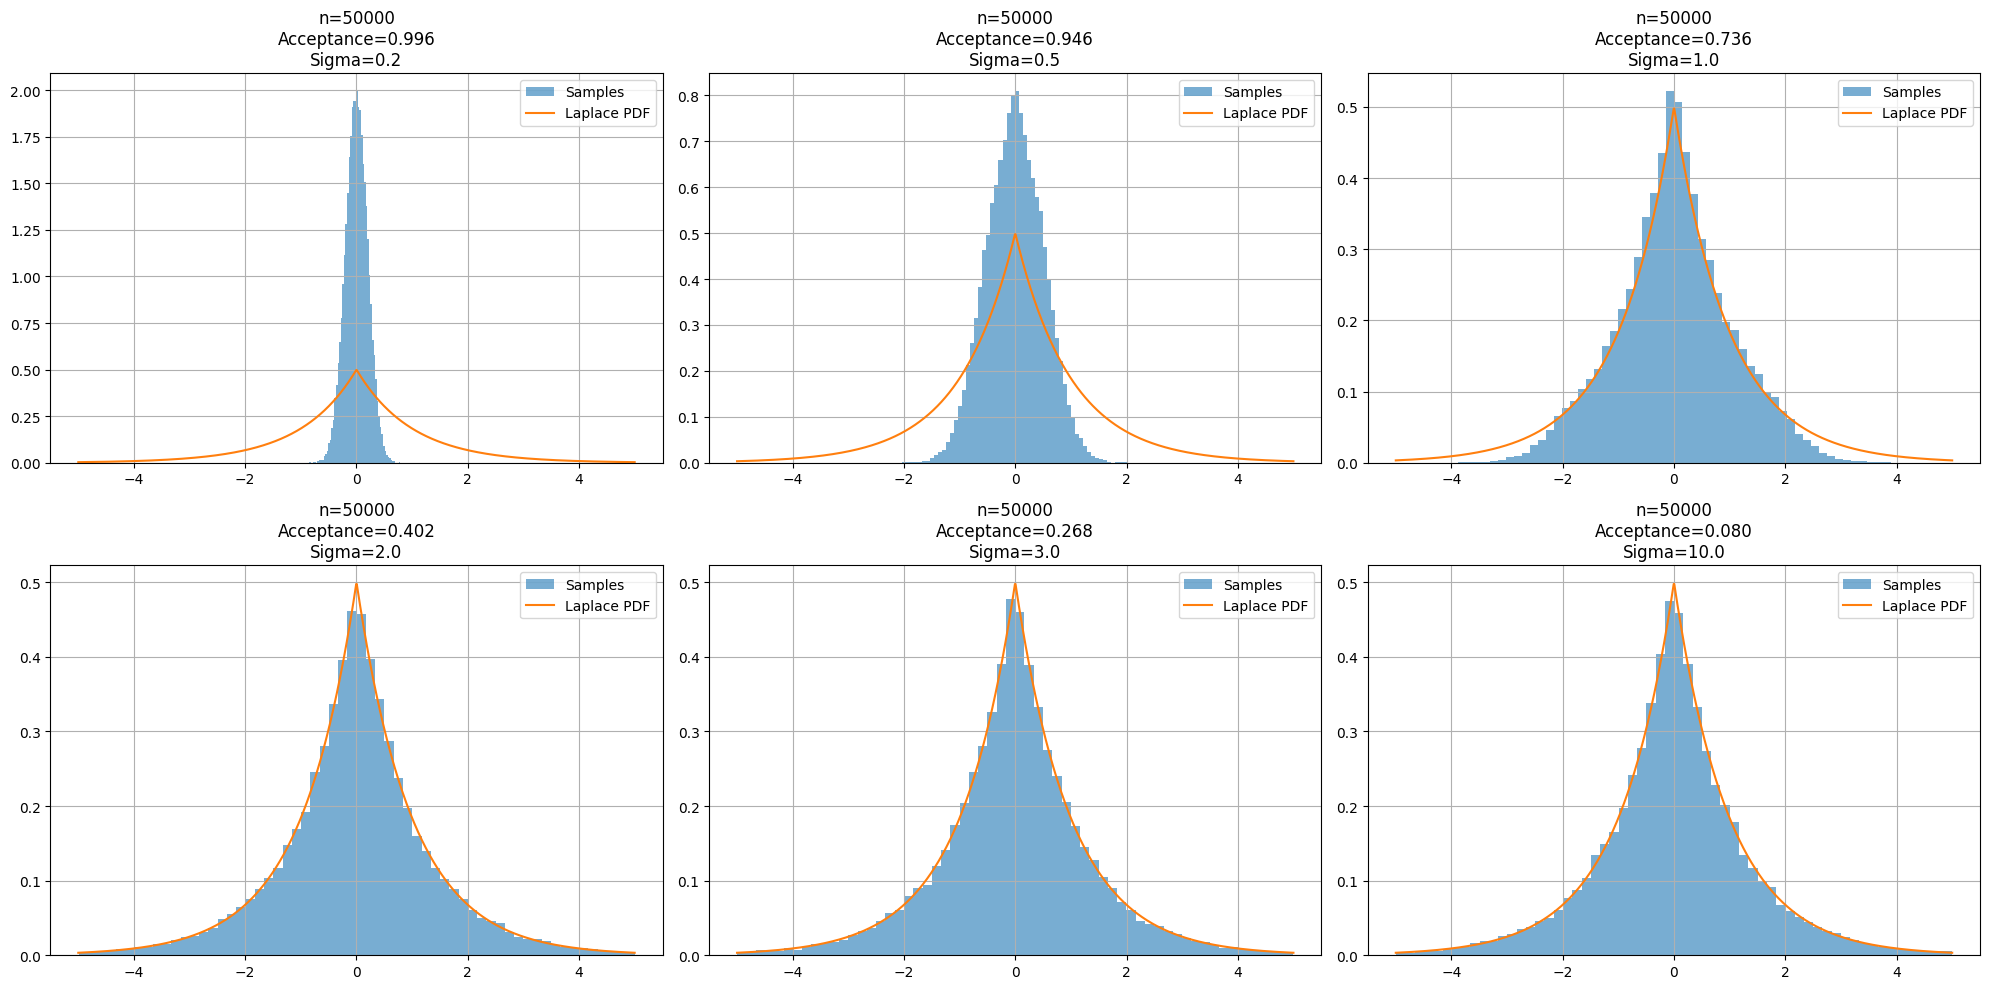

In [70]:
import numpy as np

sigmas = [0.2, 0.5, 1.0, 2.0, 3.0, 10]

# for s in sigmas:
#     samples, trials, M = rejection_sampling_laplace(5000, s)

#     acceptance_rate = len(samples) / trials
#     theoretical = 2 / M

#     print(f"σ = {s}")
#     print(f"  M = {M:.4f}")
#     print(f"  Empirical Acceptance = {acceptance_rate:.4f}")
#     print(f"  Theoretical Acceptance = {theoretical:.4f}")
#     print()

    # True Laplace PDF
x_vals = np.linspace(-5, 5, 1000)
laplace_pdf = 0.5 * np.exp(-np.abs(x_vals))

n_samples = 50000

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for ax, s in zip(axes.flatten(), sigmas):
    samples, trials, M = rejection_sampling_laplace(n_samples, sigma = s)
    acceptance_rate = len(samples) / trials
    theoretical = 2 / M

    print(f"σ = {s}")
    print(f"  M = {M:.4f}")
    print(f"  Empirical Acceptance = {acceptance_rate:.4f}")
    print(f"  Theoretical Acceptance = {theoretical:.4f}")
    print()

    # Restrict samples for fair visualization
    samples_plot = samples[(samples >= -5) & (samples <= 5)]

    ax.hist(samples_plot, bins=60, density=True, alpha=0.6, label="Samples")
    ax.plot(x_vals, laplace_pdf, label="Laplace PDF")


    ax.set_title(f"n={n_samples}\nAcceptance={acceptance_rate:.3f}\nSigma={s:.1f}")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

# Task 17.6: Curse of Dimensionality in Rejection Sampling

## Objective

We extend rejection sampling to higher dimensions and analyze how efficiency scales with dimension $d$.

---

## Target Distribution

We define:
$$
f(x) = e^{-\|x\|_1}, \quad x \in \mathbb{R}^d
$$

where:
$$
\|x\|_1 = \sum_{i=1}^d |x_i|
$$

---

## Proposal Distribution

We use:
$$
g(x) = \mathcal{N}(0, \sigma^2 I_d)
$$

with density:
$$
g(x) = \frac{1}{(2\pi\sigma^2)^{d/2}} \exp\left(-\frac{\|x\|_2^2}{2\sigma^2}\right)
$$

---

## Goal

Compute:
$$
M_d = \sup_x \frac{f(x)}{g(x)}
$$

and analyze how:
$$
P(\text{accept}) = \frac{\int f(x)\,dx}{M_d}
$$
behaves as dimension $d$ increases.

---

## Derivation of $M_d$

We compute:
$$
\frac{f(x)}{g(x)}
= (2\pi\sigma^2)^{d/2} \cdot \exp\left(-\|x\|_1 + \frac{\|x\|_2^2}{2\sigma^2}\right)
$$

Define:
$$
\phi(x) = -\|x\|_1 + \frac{\|x\|_2^2}{2\sigma^2}
$$

---

## Key Observation

The maximum occurs when only **one coordinate is non-zero**, i.e.:
$$
x = (t, 0, 0, \dots, 0)
$$

Reason:
- $\|x\|_1 = |t|$
- $\|x\|_2^2 = t^2$

If multiple coordinates are nonzero:
- $\|x\|_1$ increases linearly
- $\|x\|_2^2$ grows slower (quadratic spread)
→ ratio decreases

---

## Reduced 1D Problem

Thus maximize:
$$
\phi(t) = -|t| + \frac{t^2}{2\sigma^2}
$$

For $t \ge 0$:
$$
\phi(t) = -t + \frac{t^2}{2\sigma^2}
$$

Differentiate:
$$
\frac{d\phi}{dt} = -1 + \frac{t}{\sigma^2} = 0
\Rightarrow t = \sigma^2
$$

---

## Maximum Value

$$
\phi(\sigma^2) = -\sigma^2 + \frac{\sigma^4}{2\sigma^2}
= -\frac{\sigma^2}{2}
$$

Thus:
$$
M_d = (2\pi\sigma^2)^{d/2} \cdot e^{-\sigma^2/2}
$$

---

## Acceptance Probability

We compute:
$$
P(\text{accept}) = \frac{\int f(x)\,dx}{M_d}
$$

Since:
$$
\int f(x)\,dx = \left(\int_{-\infty}^{\infty} e^{-|x|} dx\right)^d = 2^d
$$

we get:
$$
P(\text{accept}) = \frac{2^d}{(2\pi\sigma^2)^{d/2} \cdot e^{-\sigma^2/2}}
$$

---

## Behavior with Dimension

Rewrite:
$$
P(\text{accept}) = e^{\sigma^2/2} \cdot \left(\frac{2}{\sqrt{2\pi\sigma^2}}\right)^d
$$

---

## Key Insight

- The term:
$$
\left(\frac{2}{\sqrt{2\pi\sigma^2}}\right)^d
$$
decays **exponentially in $d$**

Thus:
$$
P(\text{accept}) \to 0 \quad \text{exponentially fast}
$$

---

## Conclusion

- $M_d$ grows exponentially with $d$
- Acceptance probability decays exponentially
- Rejection sampling becomes infeasible in high dimensions

This phenomenon is known as the **curse of dimensionality**

## Compute $ M_{d} $ and Acceptance

In [71]:
import numpy as np

def compute_Md(sigma, d):
    return (2 * np.pi * sigma**2)**(d/2) * np.exp(-sigma**2 / 2)

def acceptance_probability(sigma, d):
    Md = compute_Md(sigma, d)
    return (2**d) / Md

# Evaluate for dimensions
sigma = 1.0
dimensions = [1, 2, 3, 5, 10]

print("d\tM_d\t\tAcceptance Probability")
print("-"*50)

for d in dimensions:
    Md = compute_Md(sigma, d)
    acc = acceptance_probability(sigma, d)
    print(f"{d}\t{Md:.4f}\t\t{acc:.6f}")

d	M_d		Acceptance Probability
--------------------------------------------------
1	1.5203		1.315489
2	3.8109		1.049609
3	9.5526		0.837466
5	60.0209		0.533148
10	5939.5303		0.172404


## Exponential Decay of Acceptance Probability

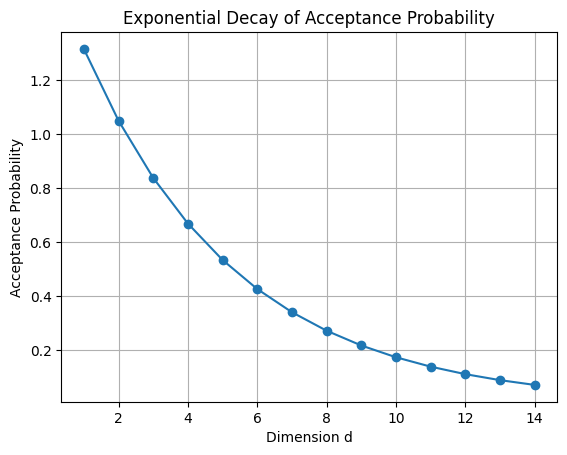

In [72]:
import matplotlib.pyplot as plt

dims = np.arange(1, 15)
sigma = 1.0

acc_vals = [acceptance_probability(sigma, d) for d in dims]

plt.figure()
plt.plot(dims, acc_vals, marker='o')
plt.xlabel("Dimension d")
plt.ylabel("Acceptance Probability")
plt.title("Exponential Decay of Acceptance Probability")
plt.grid()
plt.show()